<a href="https://colab.research.google.com/github/SaiButhongyou/229352-StatisticalLearning/blob/main/Lab09_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #9

In [41]:
%%capture
!git clone https://github.com/donlapark/ds352-labs.git

In [42]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

## Training a neural network in PyTorch

### Chihuahua or Muffin?

<center><img src="https://donlapark.pages.dev/229352/lab09-preview.jpg" width="500"/></center>

### 1. Data preparation

#### Load images, resize them to 128x128, and normalize the pixels to be in 0 - 1 range

In [43]:
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])  # transform pixels to be in 0 - 1 range

dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/train",
                                         transform=transform)

#### Split the dataset into training (80%), validation (20%)

In [44]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Load the datasets into DataLoader

In [45]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=10,
                          shuffle=True)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=len(val_dataset),
                        shuffle=False)

#### Do the same for the test images

In [46]:
test_dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/test",
                                    transform=transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

#### Looking at the first minibatch

In [47]:
train_batches = iter(train_loader)
X, y = next(train_batches)

print(X.shape)  # (batch_size, channel, height, weight)
print(y.shape)

torch.Size([10, 3, 224, 224])
torch.Size([10])


#### Visualize the first four images in the batch

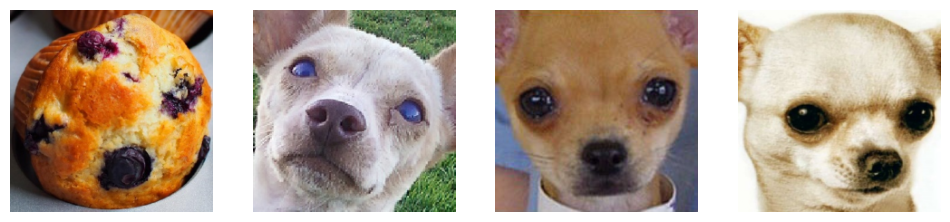

tensor([1, 0, 0, 0])


In [48]:
X = X[:4]  # Select the first 4 images
X = X.numpy().transpose(0, 2, 3, 1)  # Convert from (B, C, H, W) to (B, H, W, C)

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    axes[i].imshow(X[i])
    axes[i].axis('off')
plt.show()

print(y[:4])#1muffle 0chiwawa

### 2. Build a simple logistic regression

<center><img src="https://donlapark.pages.dev/229352/logistic.png" width="300"/></center>

The most important component of the model class is the `__init__` method and the `forward` method.  
  
[Activation functions in PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). The most important ones are [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html), [Softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html), [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

In [49]:
class SimpleLogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # แก้เป็น 224*224*3 ให้ตรงกับข้อมูลจริงที่โหลดมา
        self.lin1 = nn.Linear(224*224*3, 100)
        self.act1 = nn.ReLU()
        self.lin2 = nn.Linear(100, 50)
        self.act2 = nn.ReLU()
        self.lin3 = nn.Linear(50, 1)
        self.sigmoid = nn.Sigmoid() # ต้องมีตัวนี้เพื่อใช้กับ BCELoss

    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.lin1(x))
        x = self.act2(self.lin2(x))
        x = self.sigmoid(self.lin3(x)) # บีบค่าให้อยู่ระหว่าง 0-1
        return x

### 3. Initialize training components

#### Initialize the model and loss function

[Loss functions in PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions). Most important ones are [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [Binary cross, entropy](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), [Categorical cross entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [50]:
model = SimpleLogisticRegression()
# Use Logits version for stability
criterion = nn.BCEWithLogitsLoss()

#### Manually setting initial weights to zero for demonstration

In [51]:
with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()


#### Create two lists to collect training and validation losses

In [52]:
# List to store the loss values for plotting
train_losses = []
val_losses = []

#### Specify the learning rate

In [53]:
learning_rate = 1e-3
optimizer = optim.SGD(model.parameters(), lr=learning_rate,momentum=0.9)

### 4. Training the model with gradient descent

#### Convert the dataloader into minibatches

In [54]:
X,y=next(train_batches)

#### Make a prediction on the minibatch (Forward pass)

In [55]:
y = y.to(torch.float32)
y_hat = model(X)
y_hat = y_hat.squeeze()

#y_hat = y_hat[:, 0]
#y = y.to(torch.float32)

#### Calculate the loss function

Recall that `criterion()` is our binary cross-entropy loss (`BCELoss`).

In [56]:
# Compute the loss
train_loss=criterion(y_hat,y)
train_losses.append(train_loss)

In [57]:
train_losses

[tensor(0.7741, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)]

#### Calculate the gradient (Backward pass)

In [58]:
# Backward pass: compute the gradient of the loss w.r.t. model parameters
train_loss.backward()

In [59]:
model.parameters()

<generator object Module.parameters at 0x7c4a8387be60>

#### Perform a gradient descent step

Careful! We must not include this step in the gradient calculation, hence the use of `with torch.no_grad()`.

In [60]:
# Manually update the weights using the gradient descent rule
optimizer.step() #parameters-learning_rate*gradient_of_parameters

# Zero the gradients after updating
model.zero_grad()

#### Do the same for the validation set

Careful! Anything in the validation step must not be included in the gradient calculation, hence the use of `with torch.no_grad()`.

In [61]:
with torch.no_grad():
  for X, y in val_loader:
    y_hat = model(X)
    # y_hat = torch.sigmoid(y_hat[:, 0])
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)
    val_loss = criterion(y_hat, y)
    val_losses.append(val_loss.item())

In [62]:
print(train_losses)
print(val_losses)

[tensor(0.7741, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)]
[0.7449080348014832]


#### Combine everything together.

Repeat the previous steps for 20 **epochs** and plot the training and validation losses.

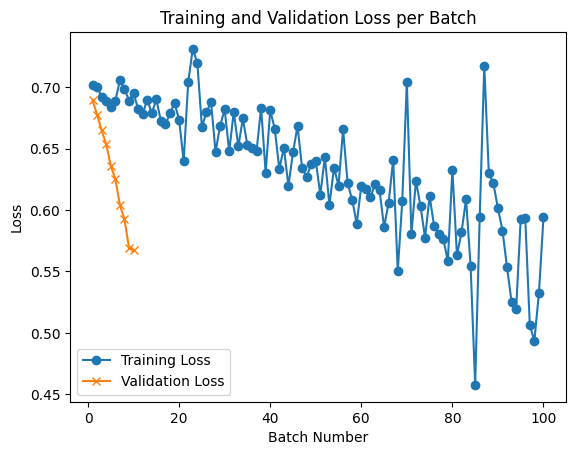

In [64]:
# 1. ตั้งค่า Hyperparameter ก่อน
learning_rate = 1e-4

# 2. สร้าง Model และ Optimizer
model = SimpleLogisticRegression()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)



train_losses = []
val_losses = []

for epoch in range(10):
    model.train() # เพิ่มโหมด Train
    for X, y in train_loader:
        optimizer.zero_grad()

        y_hat = model(X).squeeze()
        y = y.to(torch.float32)

        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval() # เพิ่มโหมด Eval สำหรับ Validation
    with torch.no_grad():
        for X, y in val_loader:
            y_hat = model(X).squeeze()
            y = y.to(torch.float32)
            val_loss = criterion(y_hat, y)
            val_losses.append(val_loss.item())


plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='x', label='Validation Loss')
plt.title('Training and Validation Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Exercise

In this exercise, we will add more layers to our classification model.

<img src="https://donlapark.pages.dev/229352/lab09-architecture.png" width="450"/>

1. Create a neural network with 3 hidden layers as shown in the picture.

2. Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.
    2.1 What value of learning rate do you **think** is the best? Please explain your reason.
    2.2 What happens to the training losses if your learning rate is too large?
    2.3 What happens to the training losses if your learning rate is too small?

3. After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.

4. Use `plt.imshow()` to display at least four images that are incorrectly classified by this model.

In [69]:
class SimpleLogisticRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.lin1 = nn.Linear(3 * 224 * 224, 128)
    self.act1=nn.ReLU()
    self.lin2=nn.Linear(128,64)
    self.act2=nn.ReLU()
    self.lin3=nn.Linear(64,32)
    self.out=nn.Linear(32,2)

  def forward(self,x):
    x=self.flatten(x)
    x=self.lin1(x)
    x=self.act1(x)
    x=self.lin2(x)
    x=self.act2(x)
    x=self.lin3(x)
    x=self.out(x)
    return x

In [71]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

In [72]:
lr_list = [1e-2, 1e-3, 1e-4, 1e-5]
all_results = {}

for lr in lr_list:
    print(f"Training with LR: {lr}")
    model = SimpleLogisticRegression() # สร้างโมเดลใหม่ทุกครั้งที่เปลี่ยน LR
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    losses = []

    for epoch in range(5):
        for X, y in train_loader:
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y.long())
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

    all_results[lr] = losses

Training with LR: 0.01
Training with LR: 0.001
Training with LR: 0.0001
Training with LR: 1e-05


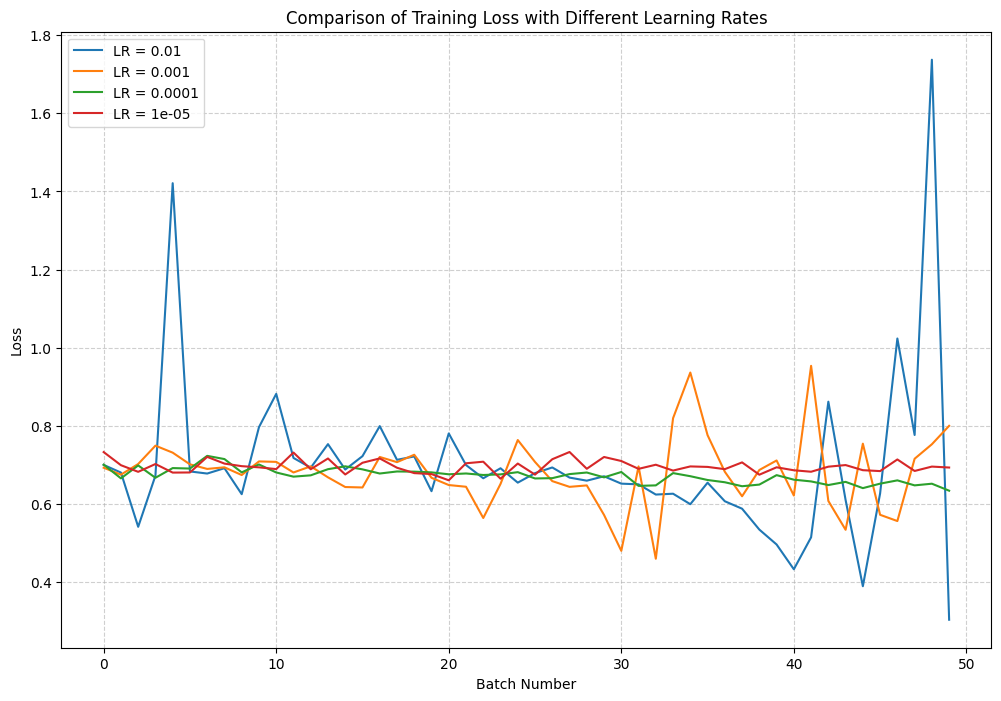

In [73]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))

for lr, losses in all_results.items():
    plt.plot(losses, label=f'LR = {lr}')

plt.title('Comparison of Training Loss with Different Learning Rates')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

จากกราฟ LR = 0.0001 (1e-4) เส้นสีเขียว ดีที่สุด เพราะมีค่าLoss ที่คงที่ ที่สุดเมื่อเทียบกับเส้นอื่น ๆ

มื่อ LR ที่ใหญ่เกินไป Loss จะเพิ่มขึ้นอย่างรวดเร็ว เมื่อWeight มันใหญ่เกินไปอาจจะทำให้โมเดลโดดข้ามจุดที่เหมาะสม เช่น LR ที่ 1e-2

เมื่อ LR เล็กเกินไป ค่า Loss จะลดลงช้าเพราะโมเดลใช้ก้าวที่เล็กเกินไปทำให้ต้องใช้เวลานานมากกว่าจะเจอจุดที่เหมาะสม

In [74]:
# Use this code to calculate test accuracy
with torch.no_grad():
  test_batches = iter(test_loader)
  X, y = next(test_batches)
  y_hat = model(X)
  y_hat = torch.argmax(y_hat, dim=1)
  corr = (y_hat == y).sum().item()
  accuracy = corr / y.size(0)# the predictions
  print(accuracy)
  ##TODO: compute accuracy


0.43333333333333335


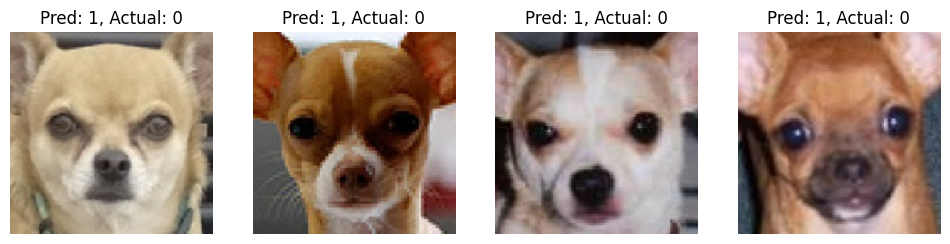

In [78]:
incorrect_indices = (y_hat != y).nonzero(as_tuple=True)[0]


plt.figure(figsize=(12, 4))
for i in range(min(4, len(incorrect_indices))):
    idx = incorrect_indices[i]
    img = X[idx].permute(1, 2, 0).cpu()

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {y_hat[idx]}, Actual: {y[idx]}")
    plt.axis('off')
plt.show()